# Chapter 10. 분류 분석으로 주문 취소 여부 예측하기

**흐름**: completed / cancelled 범위 확정 → is_cancelled Target → 예측 시점 → Feature Leakage Audit → line_total 검증 → 주문 단위 feature → 병합 검증 → 클래스 분포 → Train / Validation / Test → Pipeline → Dummy / Logistic / Random Forest → Validation 모델 선택 → Validation threshold 선택 → 모델·threshold 고정 → Final Test → FP / FN 해석 → Privacy-safe Output → Validation Evidence → 재실행 → 사용 판단

> 모델과 Threshold 선택은 Validation에서 끝내고, Final Test는 모든 선택이 끝난 뒤 마지막 평가에만 사용한다.

**실행 순서 (프로젝트 루트)**
```bash
python scripts/prepare_ch10_data.py          # data/raw → FK 검증 → data/processed
# 이 Notebook을 위에서부터 끝까지 실행 (Restart & Run All)
python scripts/run_ch10_classification.py    # 같은 코드로 전체 재실행
```

### STEP 0. 실행 환경과 Chapter10 입력 확인

In [1]:
import sys
from pathlib import Path

print(sys.executable)
print(Path.cwd())

# notebooks/ 에서 실행해도, 프로젝트 루트에서 실행해도 동작
ROOT = Path.cwd() if (Path.cwd() / "data" / "raw").exists() else Path.cwd().parent
PROCESSED = ROOT / "data" / "processed"
for f in ["customers_clean.csv", "orders_clean.csv", "order_items_clean.csv"]:
    print(f"{'✅' if (PROCESSED / f).exists() else '❌'} data/processed/{f}")
assert all((PROCESSED / f).exists() for f in ["customers_clean.csv", "orders_clean.csv", "order_items_clean.csv"]), \
    "먼저 프로젝트 루트에서 python scripts/prepare_ch10_data.py 를 실행하세요."

/usr/bin/python3
/home/claude/proj/notebooks
✅ data/processed/customers_clean.csv
✅ data/processed/orders_clean.csv
✅ data/processed/order_items_clean.csv


## 입력 준비 결과
- `scripts/prepare_ch10_data.py`: 공통 `data/raw`(customers / orders / order_items / products) 로드 → 공통 전처리 → FK 관계 검증 → PASS일 때만 `data/processed` 저장
- 원본 관계 오류 3건을 발견해 기록하고 제외했다 (Ch09와 같은 오류)
  - order_id 301: customer_id 300이 customers에 없고, product_id 200이 products에 없음 → 주문 전체 제외
  - order_id 400: order_items에만 있고 부모 주문이 없음 → 해당 상세 행 제외
- 정제 후 FK 재검증 7개 항목 모두 PASS → customers 150행, orders 300행, order_items 764행 저장
- Chapter05 오류 탐지용 Raw와 `data/raw/*_clean.csv`(이전 실습 산출물)는 사용하지 않았다.

In [2]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)

# 한글 폰트: Windows(맑은 고딕) 우선, 없으면 설치된 한글 폰트 사용
_installed = {f.name for f in font_manager.fontManager.ttflist}
for _font in ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR", "Noto Sans CJK JP"]:
    if _font in _installed:
        plt.rcParams["font.family"] = _font
        break
plt.rcParams["axes.unicode_minus"] = False

REPORTS = ROOT / "reports"
IMAGES = ROOT / "notebooks" / "images"
REPORTS.mkdir(exist_ok=True)
IMAGES.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
read = lambda f: pd.read_csv(PROCESSED / f, encoding="utf-8-sig")
customers = read("customers_clean.csv")
orders = read("orders_clean.csv")
order_items = read("order_items_clean.csv")
orders["order_date"] = pd.to_datetime(orders["order_date"])
print(f"customers {customers.shape}, orders {orders.shape}, order_items {order_items.shape}")

customers (150, 6), orders (300, 5), order_items (764, 5)


### STEP 1. Target Contract와 예측 시점 정의

In [3]:
# ===== STEP 1. Target Contract =====
TARGET = "is_cancelled"
TARGET_MAP = {"completed": 0, "cancelled": 1}          # refunded / 기타 상태 = 모델링 제외
PREDICTION_TIME = "주문 생성 직후 (결제수단·주문 상품 구성이 확정된 시점, 배송·취소 처리 이전)"

status_counts = orders["order_status"].value_counts().rename_axis("order_status").reset_index(name="rows")
status_counts["modeling_scope"] = status_counts["order_status"].map(
    lambda s: f"포함 (is_cancelled={TARGET_MAP[s]})" if s in TARGET_MAP else "제외")
display(status_counts)

scoped_orders = orders[orders["order_status"].isin(TARGET_MAP)].copy()
scoped_orders[TARGET] = scoped_orders["order_status"].map(TARGET_MAP).astype(int)
print(f"전체 주문 {len(orders)}건 → 모델링 범위(completed/cancelled) {len(scoped_orders)}건, "
      f"제외 {len(orders) - len(scoped_orders)}건")
print("예측 시점:", PREDICTION_TIME)

,order_status,rows,modeling_scope
0,completed,184,포함 (is_cancelled=0)
1,cancelled,64,포함 (is_cancelled=1)
2,refunded,52,제외


전체 주문 300건 → 모델링 범위(completed/cancelled) 248건, 제외 52건
예측 시점: 주문 생성 직후 (결제수단·주문 상품 구성이 확정된 시점, 배송·취소 처리 이전)


## Target Contract
| 질문 | 답 |
|---|---|
| 무엇을 예측하는가? | 주문이 취소될지 여부 (`is_cancelled`: completed=0, cancelled=1) |
| 예측 단위는? | 주문 1건 (order_id 1행) |
| 언제 예측하는가? | 주문 생성 직후 (결제수단과 주문 상품 구성이 확정된 시점, 배송·취소 처리 이전) |
| 그 시점에 알 수 있는 정보 | 결제수단, 주문 날짜(월·요일), 고객 특성(성별·나이·도시), 주문 상품 수·수량·금액 |
| 그 시점 이후에만 알 수 있는 정보 | order_status, 취소 사유·취소 시각, 환불 여부 등 주문 이후 결과 |

- 모델링 범위: completed 184건 + cancelled 64건 = **248건**
- refunded 52건은 제외했다. 환불은 "결제·배송 이후" 발생하는 다른 종류의 결과라서 0에 넣으면 "정상 완료"의 의미가 흐려지고, 1에 넣으면 "취소"의 정의가 바뀐다.

In [4]:
# ===== STEP 1-2. Feature Leakage Audit =====
# (예측 시점 사용 가능, 최종 사용, 구분, 판단 이유)
AUDIT_RULES = {
    # --- 허용: 주문 생성 직후 이미 알 수 있는 정보 ---
    "payment_method":  ("O", "사용", "허용",       "주문 생성 시 결제수단이 결정됨"),
    "order_month":     ("O", "사용", "허용",       "order_date에서 파생. 주문 시점에 알 수 있음"),
    "order_dayofweek": ("O", "사용", "허용",       "order_date에서 파생. 주문 시점에 알 수 있음"),
    "gender":          ("O", "사용", "허용",       "고객 비식별 특성. 주문 전부터 알 수 있음"),
    "age":             ("O", "사용", "허용",       "고객 비식별 특성. 주문 전부터 알 수 있음"),
    "city":            ("O", "사용", "허용",       "고객 비식별 특성. 주문 전부터 알 수 있음"),
    "item_count":      ("O", "사용", "허용",       "주문 상세 행 수 집계. 주문 생성 시 장바구니 구성이 확정됨"),
    "total_quantity":  ("O", "사용", "허용",       "quantity 합계. 주문 생성 시 확정됨"),
    "order_amount":    ("O", "사용", "허용",       "검증된 line_total 합계. 주문 생성 시 결제 금액이 확정됨"),
    # --- Target / 사후 정보 ---
    "is_cancelled":    ("X", "제외", "Target 자체", "예측 대상"),
    "order_status":    ("X", "제외", "사후 정보",  "Target을 만든 원천 컬럼. 주문 이후 확정되는 결과"),
    "cancel_reason":   ("X", "제외", "사후 정보",  "취소 이후에만 생성 (현재 데이터에는 없음)"),
    "cancelled_at":    ("X", "제외", "사후 정보",  "취소 이후에만 생성 (현재 데이터에는 없음)"),
    # --- 식별자 / 개인정보 ---
    "order_id":        ("X", "제외", "식별자",     "의미 없는 번호. 암기 위험"),
    "customer_id":     ("X", "제외", "식별자",     "고객 번호. 새 고객에 일반화 불가"),
    "product_id":      ("X", "제외", "식별자",     "상품 번호. 주문 단위 집계 시 사용하지 않음"),
    "order_item_id":   ("X", "제외", "식별자",     "주문 상세 행 번호"),
    "name":            ("X", "제외", "식별자",     "고객 실명 = 개인정보. 입력·공개 모두 금지"),
    # --- 행 단위 원재료 (주문 단위 feature로 집계해서만 사용) ---
    "quantity":        ("O", "제외", "집계 원재료", "행 단위 값. total_quantity로 집계해 사용"),
    "unit_price":      ("O", "제외", "집계 원재료", "행 단위 값. line_total 검증에만 사용"),
    "line_total":      ("O", "제외", "집계 원재료", "행 단위 값. order_amount로 집계해 사용"),
    # --- 기타 제외 ---
    "order_date":      ("O", "제외", "기타 제외",   "원본 날짜는 month/dayofweek로 파생해 사용"),
    "signup_date":     ("O", "제외", "기타 제외",   "주문일보다 가입일이 늦은 행이 있어 신뢰하기 어려움"),
}
FEATURES = [c for c, r in AUDIT_RULES.items() if r[1] == "사용"]
FORBIDDEN = [c for c, r in AUDIT_RULES.items() if r[1] == "제외"]
NUM_FEATURES = ["age", "order_month", "item_count", "total_quantity", "order_amount"]
CAT_FEATURES = ["payment_method", "order_dayofweek", "gender", "city"]
assert set(NUM_FEATURES + CAT_FEATURES) == set(FEATURES), "FEATURES와 전처리 컬럼 불일치"

feature_audit = pd.DataFrame(
    [(c, *r) for c, r in AUDIT_RULES.items()],
    columns=["feature", "예측 시점 사용 가능", "최종 사용", "구분", "판단 이유"])
feature_audit.to_csv(REPORTS / "ch10_feature_audit.csv", index=False, encoding="utf-8-sig")
display(feature_audit)
print("최종 FEATURES:", FEATURES)
print("💾 저장: reports/ch10_feature_audit.csv")

,feature,예측 시점 사용 가능,최종 사용,구분,판단 이유
0,payment_method,O,사용,허용,주문 생성 시 결제수단이 결정됨
1,order_month,O,사용,허용,order_date에서 파생. 주문 시점에 알 수 있음
2,order_dayofweek,O,사용,허용,order_date에서 파생. 주문 시점에 알 수 있음
3,gender,O,사용,허용,고객 비식별 특성. 주문 전부터 알 수 있음
4,age,O,사용,허용,고객 비식별 특성. 주문 전부터 알 수 있음
5,city,O,사용,허용,고객 비식별 특성. 주문 전부터 알 수 있음
6,item_count,O,사용,허용,주문 상세 행 수 집계. 주문 생성 시 장바구니 구성이 확정됨
7,total_quantity,O,사용,허용,quantity 합계. 주문 생성 시 확정됨
8,order_amount,O,사용,허용,검증된 line_total 합계. 주문 생성 시 결제 금액이 확정됨
9,is_cancelled,X,제외,Target 자체,예측 대상


최종 FEATURES: ['payment_method', 'order_month', 'order_dayofweek', 'gender', 'age', 'city', 'item_count', 'total_quantity', 'order_amount']
💾 저장: reports/ch10_feature_audit.csv


## Feature Leakage Audit 결과
- 최종 사용 feature 9개: payment_method, order_month, order_dayofweek, gender, age, city, item_count, total_quantity, order_amount
- **Target / 사후 정보**: is_cancelled, order_status (cancel_reason, cancelled_at은 현재 데이터에 없지만 규칙으로 금지)
- **식별자·개인정보**: order_id, customer_id, product_id, order_item_id, name
- **집계 원재료**: quantity, unit_price, line_total은 행 단위라 그대로 넣지 않고 주문 단위로 집계해서 사용
- **기타 제외**: order_date(파생 후 제외), signup_date(주문일보다 가입일이 늦은 주문이 48건 있어 신뢰하기 어려움)

### 나의 해석과 판단
- 파일에 존재하는 컬럼과 예측 시점에 사용할 수 있는 컬럼은 다르다. 특히 `order_status`는 Target을 만든 원천이라 넣으면 정답을 그대로 알려주는 것과 같다.
- Ch09에서는 주문 금액이 Target이라 item_count·order_amount가 금지였지만, Ch10에서는 Target이 취소 여부이고 주문 생성 시점에 장바구니 구성이 확정되므로 허용했다. **같은 컬럼도 Target과 예측 시점에 따라 허용 여부가 달라진다.**

### STEP 2. 주문 단위 특징과 계산 관계 검증

In [5]:
# ===== STEP 2. 주문 단위 특징과 line_total 계산 관계 검증 =====
items = order_items.copy()
if "line_total" not in items.columns:
    # 원본에 line_total이 없으면 계산식으로 만든다
    items["line_total"] = items["quantity"] * items["unit_price"]
expected_line_total = items["quantity"] * items["unit_price"]
line_total_mismatch = int((items["line_total"] != expected_line_total).sum())

order_item_features = (items.groupby("order_id")
    .agg(item_count=("order_item_id", "count"),
         total_quantity=("quantity", "sum"),
         order_amount=("line_total", "sum"))
    .reset_index())

dq_checks = pd.DataFrame([
    ("quantity > 0",                   int((items["quantity"] <= 0).sum())),
    ("unit_price > 0",                 int((items["unit_price"] <= 0).sum())),
    ("line_total = quantity × unit_price", line_total_mismatch),
    ("order_item_features: order_id당 1행", int(order_item_features["order_id"].duplicated().sum())),
    ("order_amount > 0",               int((order_item_features["order_amount"] <= 0).sum())),
], columns=["check", "violations"])
dq_checks["status"] = np.where(dq_checks["violations"] == 0, "PASS", "FAIL")
dq_checks.to_csv(REPORTS / "ch10_data_quality_checks.csv", index=False, encoding="utf-8-sig")
display(dq_checks)
assert (dq_checks["status"] == "PASS").all(), "데이터 품질 문제를 먼저 해결해야 합니다."
display(order_item_features.describe().round(1))
print("💾 저장: reports/ch10_data_quality_checks.csv")

,check,violations,status
0,quantity > 0,0,PASS
1,unit_price > 0,0,PASS
2,line_total = quantity × unit_price,0,PASS
3,order_item_features: order_id당 1행,0,PASS
4,order_amount > 0,0,PASS


,order_id,item_count,total_quantity,order_amount
count,300.0,300.0,300.0,300.0
mean,150.5,2.5,7.8,852033.3
std,86.7,1.1,4.0,515967.4
min,1.0,1.0,1.0,10000.0
25%,75.8,2.0,5.0,413750.0
50%,150.5,3.0,7.0,807000.0
75%,225.2,3.2,11.0,1173000.0
max,300.0,4.0,19.0,2821000.0


💾 저장: reports/ch10_data_quality_checks.csv


## line_total 검증과 주문 단위 특징
- 원본 order_items에는 line_total이 없어서 `quantity × unit_price`로 만들고, 계산식과 일치하는지 다시 확인했다 → 불일치 0건
- quantity > 0, unit_price > 0 위반 0건
- order_id당 1행으로 집계: item_count(주문 상품 행 수), total_quantity(수량 합계), order_amount(line_total 합계)
- 주문 300건 기준 item_count 1~4, order_amount 1만 원 ~ 282만 1천 원, 평균 약 85만 원
- 데이터 품질 검증 5개 항목 모두 PASS → 모델 학습으로 진행

### STEP 3. 병합 관계와 Feature Audit 확인

In [6]:
# ===== STEP 3. 병합 관계 검증 (미매칭을 fillna(0)으로 숨기지 않음) =====
rows_before = len(scoped_orders)

m1 = scoped_orders.merge(order_item_features, on="order_id", how="left",
                         validate="one_to_one", indicator="_m_items")
unmatched_items = int((m1["_m_items"] != "both").sum())

model_df = m1.drop(columns="_m_items").merge(
    customers[["customer_id", "gender", "age", "city"]], on="customer_id", how="left",
    validate="many_to_one", indicator="_m_cust")
unmatched_customers = int((model_df["_m_cust"] != "both").sum())
model_df = model_df.drop(columns="_m_cust")

# 주문 시점 파생 feature
model_df["order_month"] = model_df["order_date"].dt.month
model_df["order_dayofweek"] = model_df["order_date"].dt.day_name()
missing_required = int(model_df[FEATURES].isna().any(axis=1).sum())

merge_checks = pd.DataFrame([
    ("orders ↔ order_item_features", "one_to_one",  rows_before, len(m1),       unmatched_items),
    ("orders → customers",           "many_to_one", len(m1),     len(model_df), unmatched_customers),
    ("필수 feature 결측 행",           "-",           len(model_df), len(model_df), missing_required),
], columns=["merge", "validate", "rows_before", "rows_after", "unmatched_count"])
merge_checks["status"] = np.where(
    (merge_checks["rows_before"] == merge_checks["rows_after"]) & (merge_checks["unmatched_count"] == 0),
    "PASS", "FAIL")
merge_checks.to_csv(REPORTS / "ch10_merge_checks.csv", index=False, encoding="utf-8-sig")
display(merge_checks)
assert (merge_checks["status"] == "PASS").all(), "병합 문제 원인을 먼저 확인하세요."

# Feature Audit 재확인: 입력에 target·식별자·사후 정보가 없는지
forbidden_overlap = sorted(set(FEATURES) & set(FORBIDDEN) | ({TARGET, "order_status"} & set(FEATURES)))
print("forbidden_feature_overlap:", forbidden_overlap if forbidden_overlap else "없음 (PASS)")
print("💾 저장: reports/ch10_merge_checks.csv")

,merge,validate,rows_before,rows_after,unmatched_count,status
0,orders ↔ order_item_features,one_to_one,248,248,0,PASS
1,orders → customers,many_to_one,248,248,0,PASS
2,필수 feature 결측 행,-,248,248,0,PASS


forbidden_feature_overlap: 없음 (PASS)
💾 저장: reports/ch10_merge_checks.csv


## 병합 검증
| 병합 | validate | 병합 전 | 병합 후 | unmatched | 결과 |
|---|---|---|---|---|---|
| orders ↔ order_item_features | one_to_one | 248 | 248 | 0 | PASS |
| orders → customers | many_to_one | 248 | 248 | 0 | PASS |
| 필수 feature 결측 | - | 248 | 248 | 0 | PASS |

- `how="left"` + `indicator`로 병합해서 미매칭을 숨기지 않고 셌다. 미매칭이 있었다면 `fillna(0)`으로 채우지 않고 원인부터 확인했을 것이다.
- forbidden_feature_overlap: 0 → target, 식별자, 사후 정보가 입력에 없다.

### STEP 4. 클래스 분포와 Dummy Baseline 확인

,is_cancelled,label,rows,ratio
0,0,completed,184,0.7419
1,1,cancelled,64,0.2581


모든 주문을 completed(0)로만 예측해도 accuracy = 0.742, cancelled recall = 0.000


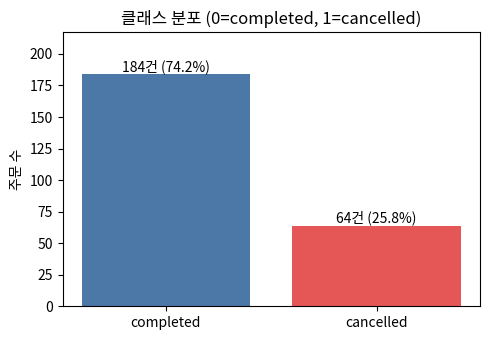

💾 저장: reports/ch10_target_distribution.csv, notebooks/images/ch10_step02_class_ratio.png


In [7]:
# ===== STEP 4. 클래스 분포 =====
target_dist = (model_df[TARGET].value_counts().sort_index()
               .rename_axis(TARGET).reset_index(name="rows"))
target_dist["label"] = target_dist[TARGET].map({0: "completed", 1: "cancelled"})
target_dist["ratio"] = (target_dist["rows"] / target_dist["rows"].sum()).round(4)
target_dist = target_dist[[TARGET, "label", "rows", "ratio"]]
target_dist.to_csv(REPORTS / "ch10_target_distribution.csv", index=False, encoding="utf-8-sig")
display(target_dist)

majority_acc = target_dist["ratio"].max()
print(f"모든 주문을 completed(0)로만 예측해도 accuracy = {majority_acc:.3f}, cancelled recall = 0.000")

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(target_dist["label"], target_dist["rows"], color=["#4C78A8", "#E45756"])
for b, (n, r) in zip(bars, zip(target_dist["rows"], target_dist["ratio"])):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{n}건 ({r:.1%})", ha="center", va="bottom")
ax.set_title("클래스 분포 (0=completed, 1=cancelled)")
ax.set_ylabel("주문 수")
ax.set_ylim(0, target_dist["rows"].max() * 1.18)
fig.tight_layout()
fig.savefig(IMAGES / "ch10_step02_class_ratio.png", dpi=120)
plt.show()
print("💾 저장: reports/ch10_target_distribution.csv, notebooks/images/ch10_step02_class_ratio.png")

## 클래스 분포
| 클래스 | 건수 | 비율 |
|---|---|---|
| 0 = completed | 184 | 74.2% |
| 1 = cancelled | 64 | 25.8% |

### 결과 관찰
- 약 3:1의 불균형 데이터다.
- 모든 주문을 completed로 예측하는 Dummy Most Frequent도 accuracy 0.742를 얻지만 cancelled recall은 0이다.

### 나의 해석과 판단
- accuracy만 보면 "아무것도 배우지 않은 모델"도 74%로 좋아 보인다. 이번 목적은 **취소 주문을 찾는 것**이므로 cancelled 클래스의 Precision / Recall / F1을 함께 봐야 한다.
- 반대로 "전부 취소로 예측"하면 recall은 1이 되지만 precision은 약 0.26에 머문다. 그래서 STEP 7에서 이 규칙(Always Cancelled)도 참고 기준으로 함께 놓았다.

### STEP 5. Train / Validation / Test 역할 구분

In [8]:
# ===== STEP 5. Train / Validation / Test (stratified random split, 60/20/20) =====
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(model_df, test_size=0.4, stratify=model_df[TARGET],
                                     random_state=RANDOM_STATE)
valid_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df[TARGET],
                                     random_state=RANDOM_STATE)
X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_valid, y_valid = valid_df[FEATURES], valid_df[TARGET]
X_test,  y_test  = test_df[FEATURES],  test_df[TARGET]

SPLIT_ROLE = {"train": "파라미터 학습", "validation": "모델 선택 + threshold 선택",
              "test": "모든 선택이 끝난 뒤 마지막 평가"}
split_summary = pd.DataFrame([
    {"split": name, "role": SPLIT_ROLE[name], "rows": len(d),
     "completed_0": int((d[TARGET] == 0).sum()), "cancelled_1": int((d[TARGET] == 1).sum()),
     "cancel_ratio": round(d[TARGET].mean(), 4),
     "date_min": d["order_date"].min().date(), "date_max": d["order_date"].max().date()}
    for name, d in [("train", train_df), ("validation", valid_df), ("test", test_df)]])
split_summary.to_csv(REPORTS / "ch10_split_summary.csv", index=False, encoding="utf-8-sig")
display(split_summary)
assert (split_summary[["completed_0", "cancelled_1"]] > 0).all().all(), "모든 split에 두 클래스가 있어야 합니다."
assert not (set(train_df["order_id"]) & set(valid_df["order_id"]) | set(train_df["order_id"]) & set(test_df["order_id"])
            | set(valid_df["order_id"]) & set(test_df["order_id"])), "split 간 주문 중복"
print("※ 세 split의 날짜 범위가 겹친다 = random split이라 미래 주문이 Train에 섞여 있음 (교육용 한계)")
print("💾 저장: reports/ch10_split_summary.csv")

,split,role,rows,completed_0,cancelled_1,cancel_ratio,date_min,date_max
0,train,파라미터 학습,148,110,38,0.2568,2025-08-13,2026-08-08
1,validation,모델 선택 + threshold 선택,50,37,13,0.2600,2025-08-22,2026-08-08
2,test,모든 선택이 끝난 뒤 마지막 평가,50,37,13,0.2600,2025-08-08,2026-08-08


※ 세 split의 날짜 범위가 겹친다 = random split이라 미래 주문이 Train에 섞여 있음 (교육용 한계)
💾 저장: reports/ch10_split_summary.csv


## Split 요약 (stratified random split, 60 / 20 / 20, random_state=42)
| split | 역할 | 행 | completed | cancelled | 취소 비율 |
|---|---|---|---|---|---|
| Train | 파라미터 학습 | 148 | 110 | 38 | 25.7% |
| Validation | 모델 선택 + threshold 선택 | 50 | 37 | 13 | 26.0% |
| Test | 모든 선택이 끝난 뒤 마지막 평가 | 50 | 37 | 13 | 26.0% |

- 세 split 모두 0과 1이 존재하고, 클래스 비율이 거의 같게 유지됐다. split 간 주문 중복 0건.

### 한계
- 세 split의 날짜 범위가 모두 2025-08 ~ 2026-08로 겹친다. random split이라 **미래 주문이 Train에 섞여 있다.** 이번 결과는 교육용이며, 실제 미래 주문 예측에 쓰려면 out-of-time 평가(과거로 학습 → 이후 기간으로 평가)와 시간 순서 검증이 필요하다.
- Validation과 Test가 각각 50건(취소 13건)뿐이라, 취소 1건만 맞히거나 틀려도 recall이 약 0.077씩 변한다.

### STEP 6. Pipeline 전처리 확인

In [9]:
# ===== STEP 6. Pipeline 전처리 (Train에서만 fit) =====
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

def make_preprocessor():
    num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")),
                         ("scaler", StandardScaler())])
    cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                         ("onehot", OneHotEncoder(handle_unknown="ignore"))])
    return ColumnTransformer([("num", num_pipe, NUM_FEATURES), ("cat", cat_pipe, CAT_FEATURES)])

CANDIDATES = {
    "Dummy Most Frequent": DummyClassifier(strategy="most_frequent"),
    "Always Cancelled (참고)": DummyClassifier(strategy="constant", constant=1),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced",
                                              random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=5, min_samples_leaf=5,
                                            class_weight="balanced", random_state=RANDOM_STATE),
}
BASELINE_NAME = "Dummy Most Frequent"
REFERENCE_NAMES = ["Always Cancelled (참고)"]   # 전부 취소로 예측하는 규칙: recall=1일 때의 비교 기준 (선택 대상 아님)
pipelines = {name: Pipeline([("prep", make_preprocessor()), ("model", est)])
             for name, est in CANDIDATES.items()}

# 확인: 전처리가 Train에서 학습한 범주만 알고 있는지
_prep = make_preprocessor().fit(X_train)
print("Train에서 학습한 city 범주:", list(_prep.named_transformers_["cat"]
      .named_steps["onehot"].categories_[CAT_FEATURES.index("city")]))
print("변환 후 feature 수:", _prep.transform(X_train).shape[1])

Train에서 학습한 city 범주: ['고양', '광주', '대구', '대전', '부산', '서울', '성남', '수원', '울산', '인천']
변환 후 feature 수: 28


## 전처리 누수 방지
- 숫자형(age, order_month, item_count, total_quantity, order_amount): median imputation → StandardScaler
- 범주형(payment_method, order_dayofweek, gender, city): most_frequent imputation → OneHotEncoder(handle_unknown="ignore")
- 전처리는 Pipeline 안에 있어서 `fit(X_train)` 때 Train으로만 학습되고, Validation / Test에는 Train에서 배운 평균·표준편차·범주만 적용된다.
- 불균형 대응으로 Logistic Regression과 Random Forest에 `class_weight="balanced"`를 사용했다. (데이터를 복제하거나 합성하지 않음)

### STEP 7. Validation에서 후보 모델 비교

,model,role,accuracy,precision,recall,f1,roc_auc,pred_cancelled,selected
0,Dummy Most Frequent,baseline,0.74,0.0000,0.0000,0.0000,0.500,0,False
1,Always Cancelled (참고),reference,0.26,0.2600,1.0000,0.4127,0.500,50,False
2,Logistic Regression,candidate,0.56,0.2632,0.3846,0.3125,0.501,19,True
3,Random Forest,candidate,0.58,0.0000,0.0000,0.0000,0.368,8,False


✅ selected_model_name = Logistic Regression  (Validation F1 → Recall → Precision 기준)


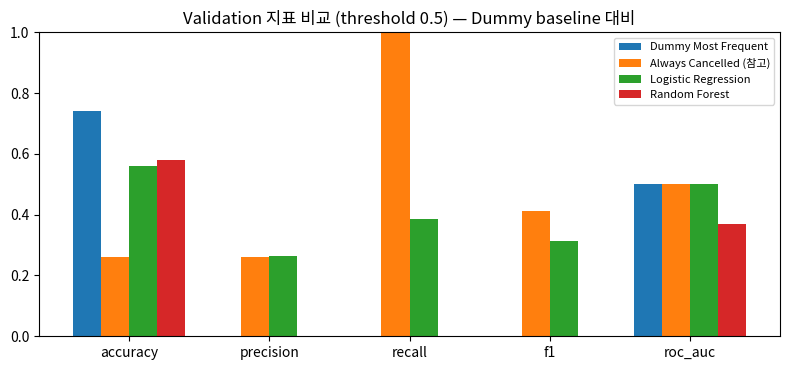

💾 저장: reports/ch10_validation_model_comparison.csv, notebooks/images/ch10_step03_baseline.png


In [10]:
# ===== STEP 7. Validation에서 후보 모델 비교 (Test는 아직 보지 않음) =====
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def clf_metrics(y_true, y_pred):
    return {"accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0)}

rows = []
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)                       # 전처리 + 모델 모두 Train에서만 fit
    pred = pipe.predict(X_valid)                     # 기본 threshold 0.5
    role = "baseline" if name == BASELINE_NAME else "reference" if name in REFERENCE_NAMES else "candidate"
    rows.append({"model": name, "role": role, **clf_metrics(y_valid, pred),
                 "roc_auc": roc_auc_score(y_valid, pipe.predict_proba(X_valid)[:, 1]),
                 "pred_cancelled": int(pred.sum())})
val_comparison = pd.DataFrame(rows)
val_comparison[["accuracy", "precision", "recall", "f1", "roc_auc"]] = val_comparison[["accuracy", "precision", "recall", "f1", "roc_auc"]].round(4)

# 선택 규칙: 비베이스라인 후보 중 F1 → Recall → Precision 순
ranked = (val_comparison[val_comparison["role"] == "candidate"]
          .sort_values(["f1", "recall", "precision"], ascending=False))
selected_model_name = ranked.iloc[0]["model"]
val_comparison["selected"] = val_comparison["model"] == selected_model_name
val_comparison.to_csv(REPORTS / "ch10_validation_model_comparison.csv", index=False, encoding="utf-8-sig")
display(val_comparison)
print(f"✅ selected_model_name = {selected_model_name}  (Validation F1 → Recall → Precision 기준)")

fig, ax = plt.subplots(figsize=(8, 3.8))
mets = ["accuracy", "precision", "recall", "f1", "roc_auc"]
w = 0.8 / len(val_comparison)
for i, (_, r) in enumerate(val_comparison.iterrows()):
    ax.bar(np.arange(len(mets)) + (i - (len(val_comparison) - 1) / 2) * w, r[mets].astype(float), w, label=r["model"])
ax.set_xticks(np.arange(len(mets)), mets)
ax.set_ylim(0, 1)
ax.set_title("Validation 지표 비교 (threshold 0.5) — Dummy baseline 대비")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(IMAGES / "ch10_step03_baseline.png", dpi=120)
plt.show()
print("💾 저장: reports/ch10_validation_model_comparison.csv, notebooks/images/ch10_step03_baseline.png")

## Validation 후보 모델 비교 (threshold 0.5)
| 모델 | 역할 | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|---|
| Dummy Most Frequent | baseline | 0.740 | 0.000 | 0.000 | 0.000 | 0.500 |
| Always Cancelled | 참고 | 0.260 | 0.260 | 1.000 | 0.413 | 0.500 |
| **Logistic Regression** | 후보 | 0.560 | 0.263 | 0.385 | 0.313 | 0.501 |
| Random Forest | 후보 | 0.580 | 0.000 | 0.000 | 0.000 | 0.368 |

### 결과 관찰
- 규칙(비베이스라인 후보 중 F1 → Recall → Precision)에 따라 **selected_model_name = Logistic Regression**. Test를 보기 전에 결정했다.
- Logistic Regression은 Dummy와 달리 취소 13건 중 5건을 찾았지만 precision 0.263은 전체 취소 비율(0.26)과 거의 같다.
- Random Forest는 취소로 예측한 8건이 모두 틀렸다(precision 0). ROC-AUC 0.368로 무작위(0.5)보다도 낮다.

### 나의 해석과 판단
- Dummy보다 나아진 점: cancelled를 실제로 예측하기 시작해서 recall이 0 → 0.385가 됐다.
- 하지만 Validation ROC-AUC 0.501은 **확률 순위가 무작위 수준**이라는 뜻이다. 현재 feature로는 취소 주문과 완료 주문을 구분하는 신호가 거의 없을 수 있다. (가설)
- Logistic을 고른 것은 "좋아서"라기보다 "Random Forest보다 덜 나빠서"에 가깝다.

### STEP 8. Validation에서 Threshold 선택 → 모델·Threshold 고정

,threshold,accuracy,precision,recall,f1,pred_cancelled,TP,FP,FN,TN,selected
0,0.05,0.26,0.2600,1.0000,0.4127,50,13,37,0,0,False
1,0.10,0.30,0.2708,1.0000,0.4262,48,13,35,0,2,False
2,0.15,0.34,0.2826,1.0000,0.4407,46,13,33,0,4,False
3,0.20,0.38,0.2955,1.0000,0.4561,44,13,31,0,6,True
4,0.25,0.40,0.2927,0.9231,0.4444,41,12,29,1,8,False
5,0.30,0.42,0.2647,0.6923,0.3830,34,9,25,4,12,False
6,0.35,0.38,0.2188,0.5385,0.3111,32,7,25,6,12,False
7,0.40,0.44,0.2414,0.5385,0.3333,29,7,22,6,15,False
8,0.45,0.46,0.2308,0.4615,0.3077,26,6,20,7,17,False
9,0.50,0.56,0.2632,0.3846,0.3125,19,5,14,8,23,False


🔒 고정: {'selected_model_name': 'Logistic Regression', 'selected_threshold': 0.2, 'selected_on': 'validation', 'rule': 'F1 > Recall > Precision', 'validation_f1_at_threshold': 0.4561}


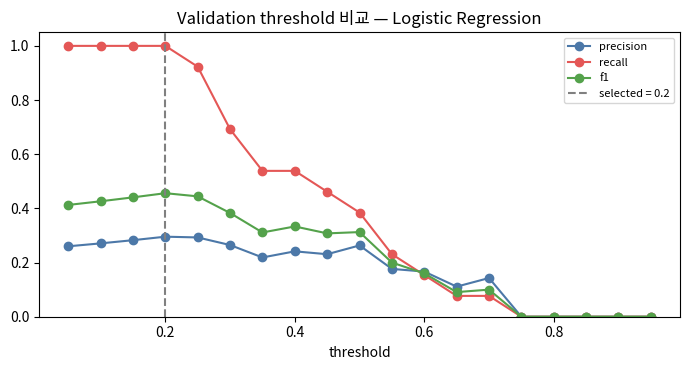

💾 저장: reports/ch10_validation_threshold_metrics.csv, reports/ch10_frozen_selection.json, notebooks/images/ch10_step05_threshold.png


In [11]:
# ===== STEP 8. Validation에서 Threshold 선택 =====
selected_pipe = pipelines[selected_model_name]          # Train에서 fit된 상태
val_proba = selected_pipe.predict_proba(X_valid)[:, 1]

THRESHOLDS = np.round(np.arange(0.05, 0.96, 0.05), 2)
th_rows = []
for t in THRESHOLDS:
    pred = (val_proba >= t).astype(int)
    tn = int(((pred == 0) & (y_valid == 0)).sum()); fp = int(((pred == 1) & (y_valid == 0)).sum())
    fn = int(((pred == 0) & (y_valid == 1)).sum()); tp = int(((pred == 1) & (y_valid == 1)).sum())
    th_rows.append({"threshold": t, **clf_metrics(y_valid, pred),
                    "pred_cancelled": int(pred.sum()), "TP": tp, "FP": fp, "FN": fn, "TN": tn})
threshold_metrics = pd.DataFrame(th_rows)
threshold_metrics[["accuracy", "precision", "recall", "f1"]] = threshold_metrics[["accuracy", "precision", "recall", "f1"]].round(4)

# 선택 규칙: F1 → Recall → Precision 순 (동점이면 recall이 높은 쪽 = 취소를 놓치지 않는 쪽)
selected_threshold = float(threshold_metrics.sort_values(["f1", "recall", "precision"], ascending=False)
                           .iloc[0]["threshold"])
threshold_metrics["selected"] = threshold_metrics["threshold"] == selected_threshold
threshold_metrics.to_csv(REPORTS / "ch10_validation_threshold_metrics.csv", index=False, encoding="utf-8-sig")
display(threshold_metrics)

# ===== 모델·threshold 고정 (이 시점 이후 변경 금지) =====
FROZEN = {"selected_model_name": selected_model_name, "selected_threshold": selected_threshold,
          "selected_on": "validation", "rule": "F1 > Recall > Precision",
          "validation_f1_at_threshold": float(threshold_metrics.loc[threshold_metrics["selected"], "f1"].iloc[0])}
(REPORTS / "ch10_frozen_selection.json").write_text(json.dumps(FROZEN, ensure_ascii=False, indent=2), encoding="utf-8")
print("🔒 고정:", FROZEN)

fig, ax = plt.subplots(figsize=(7, 3.8))
for m, c in [("precision", "#4C78A8"), ("recall", "#E45756"), ("f1", "#54A24B")]:
    ax.plot(threshold_metrics["threshold"], threshold_metrics[m], marker="o", label=m, color=c)
ax.axvline(selected_threshold, color="gray", ls="--", label=f"selected = {selected_threshold}")
ax.set_xlabel("threshold"); ax.set_ylim(0, 1.05)
ax.set_title(f"Validation threshold 비교 — {selected_model_name}")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(IMAGES / "ch10_step05_threshold.png", dpi=120)
plt.show()
print("💾 저장: reports/ch10_validation_threshold_metrics.csv, reports/ch10_frozen_selection.json, "
      "notebooks/images/ch10_step05_threshold.png")

## Validation Threshold 비교 (Logistic Regression)
| threshold | Precision | Recall | F1 | 취소 예측 수 | FP | FN |
|---|---|---|---|---|---|---|
| 0.05 | 0.260 | 1.000 | 0.413 | 50 | 37 | 0 |
| **0.20** | **0.296** | **1.000** | **0.456** | 44 | 31 | 0 |
| 0.30 | 0.265 | 0.692 | 0.383 | 34 | 25 | 4 |
| 0.50 | 0.263 | 0.385 | 0.313 | 19 | 14 | 8 |
| 0.70 | 0.143 | 0.077 | 0.100 | 7 | 6 | 12 |

### 결과 관찰
- threshold를 낮추자 recall이 증가하고 FP도 증가했다 (0.5 → 0.2: recall 0.385 → 1.0, FP 14 → 31).
- threshold를 높여도 precision이 오르지 않았다 (0.7에서 0.143). 확률이 높은 주문일수록 실제로 취소될 가능성이 높다는 관계가 Validation에서 보이지 않는다.
- 규칙(F1 → Recall → Precision)에 따라 **selected_threshold = 0.20** (Validation F1 0.456).

### 나의 해석과 판단
- 0.20은 50건 중 44건을 취소 위험으로 표시한다. 사실상 "거의 전부 취소로 예측"하는 것과 비슷하고, Always Cancelled(F1 0.413) 대비 개선은 완료 주문 6건을 걸러낸 정도다.
- F1은 precision과 recall을 똑같이 중시한다. 취소 위험 주문에 **저비용 조치**(안내 알림, 재고 가예약 해제 준비 등)를 한다면 FN을 줄이는 낮은 threshold가 맞을 수 있다. 반대로 **고비용 조치**(주문 보류, 상담 전화)를 한다면 FP 비용이 커서 0.2는 과하다.
- 가설: 취소 주문을 더 많이 탐지하려면 추가 FP 비용을 감수해야 한다. 다만 현재 모델은 threshold를 높여도 precision이 오르지 않아서, threshold 조정만으로 FP를 줄이기 어렵다.

## 고정된 선택 (Final Test 전)
- selected_model_name: **Logistic Regression**
- selected_threshold: **0.20**
- 기록: `reports/ch10_frozen_selection.json`

### STEP 9. Final Test 평가 (고정된 모델·threshold로 한 번만)

In [12]:
# ===== STEP 9. Final Test (고정된 모델·threshold로 딱 한 번 평가) =====
frozen = json.loads((REPORTS / "ch10_frozen_selection.json").read_text(encoding="utf-8"))
assert frozen["selected_model_name"] == selected_model_name and frozen["selected_threshold"] == selected_threshold

final_pipe = pipelines[frozen["selected_model_name"]]   # Train에서 fit된 모델 그대로 (재학습·재선택 없음)
test_proba = final_pipe.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= frozen["selected_threshold"]).astype(int)

test_metrics = pd.DataFrame([
    {"model": frozen["selected_model_name"], "threshold": frozen["selected_threshold"], "role": "frozen selected",
     **clf_metrics(y_test, test_pred), "roc_auc": roc_auc_score(y_test, test_proba)},
    *[{"model": n, "threshold": "-", "role": "baseline 참고" if n == BASELINE_NAME else "reference 참고",
       **clf_metrics(y_test, pipelines[n].predict(X_test)), "roc_auc": 0.5}
      for n in [BASELINE_NAME, *REFERENCE_NAMES]],
])
test_metrics[["accuracy", "precision", "recall", "f1", "roc_auc"]] = test_metrics[["accuracy", "precision", "recall", "f1", "roc_auc"]].round(4)
test_metrics["test_rows"] = len(y_test)
test_metrics.to_csv(REPORTS / "ch10_test_metrics.csv", index=False, encoding="utf-8-sig")
display(test_metrics)
print("※ 이 결과를 보고 모델이나 threshold를 다시 고르지 않습니다.")
print("💾 저장: reports/ch10_test_metrics.csv")

,model,threshold,role,accuracy,precision,recall,f1,roc_auc,test_rows
0,Logistic Regression,0.2,frozen selected,0.34,0.2826,1.0,0.4407,0.7173,50
1,Dummy Most Frequent,-,baseline 참고,0.74,0.0000,0.0,0.0000,0.5000,50
2,Always Cancelled (참고),-,reference 참고,0.26,0.2600,1.0,0.4127,0.5000,50


※ 이 결과를 보고 모델이나 threshold를 다시 고르지 않습니다.
💾 저장: reports/ch10_test_metrics.csv


## Final Test 결과 (50건, 취소 13건)
| 모델 | threshold | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|---|
| **Logistic Regression (frozen)** | 0.20 | 0.340 | 0.283 | 1.000 | 0.441 | 0.717 |
| Dummy Most Frequent | - | 0.740 | 0.000 | 0.000 | 0.000 | 0.500 |
| Always Cancelled (참고) | - | 0.260 | 0.260 | 1.000 | 0.413 | 0.500 |

### 결과 관찰
- 취소 13건을 모두 찾았지만(recall 1.0), 취소 위험으로 표시한 46건 중 33건이 실제로는 완료 주문이었다(precision 0.283).
- Accuracy 0.34는 Dummy(0.74)보다 훨씬 낮다. 대부분을 취소로 예측했기 때문이다.
- F1은 Always Cancelled보다 0.028 높을 뿐이다 (완료 주문 4건을 걸러낸 차이).
- Test ROC-AUC 0.717은 Validation 0.501과 차이가 크다.

### 나의 해석과 판단
- Accuracy, Precision, Recall, F1을 함께 보면 "취소를 놓치지 않는다"는 recall 1.0은 threshold를 낮게 잡은 결과이지, 모델이 취소를 잘 구분해서 나온 것이 아니다.
- ROC-AUC가 Validation(0.50)과 Test(0.72)에서 크게 다른 것은 50건이라는 작은 표본에서 생기는 변동일 가능성이 높다. (가설) Test 결과가 더 좋아 보인다고 해서 Test를 보고 threshold를 다시 고르지 않는다. 추가 실험이 필요하면 새로운 Validation 설계나 새 holdout 데이터가 필요하다.

### STEP 10. Confusion Matrix와 FP/FN 해석

,pred_0_completed,pred_1_cancelled
actual_0_completed,4,33
actual_1_cancelled,0,13


TN=4 (완료→완료) | FP=33 (완료→취소 위험) | FN=0 (취소→완료) | TP=13 (취소→취소 위험)


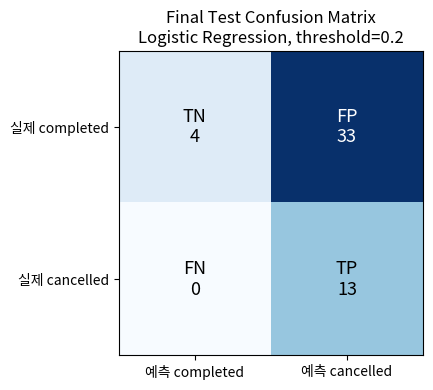

,rows,mean_proba,mean_amount,mean_items,mean_age
case,,,,,
FP,33,0.491,863454.545,2.515,41.545
TN,4,0.154,373750.000,2.250,46.750
TP,13,0.621,1170076.923,2.385,37.769


💾 저장: reports/ch10_confusion_matrix.csv, notebooks/images/ch10_step06_confusion_matrix.png


In [13]:
# ===== STEP 10. Confusion Matrix와 FP/FN =====
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, test_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
cm_df = pd.DataFrame(cm, index=["actual_0_completed", "actual_1_cancelled"],
                     columns=["pred_0_completed", "pred_1_cancelled"])
cm_df.to_csv(REPORTS / "ch10_confusion_matrix.csv", encoding="utf-8-sig")
display(cm_df)
print(f"TN={tn} (완료→완료) | FP={fp} (완료→취소 위험) | FN={fn} (취소→완료) | TP={tp} (취소→취소 위험)")

fig, ax = plt.subplots(figsize=(4.6, 4))
ax.imshow(cm, cmap="Blues")
labels = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{labels[i][j]}\n{cm[i, j]}", ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=13)
ax.set_xticks([0, 1], ["예측 completed", "예측 cancelled"])
ax.set_yticks([0, 1], ["실제 completed", "실제 cancelled"])
ax.set_title(f"Final Test Confusion Matrix\n{selected_model_name}, threshold={selected_threshold}")
fig.tight_layout()
fig.savefig(IMAGES / "ch10_step06_confusion_matrix.png", dpi=120)
plt.show()

# 오류 사례의 feature 경향 (Internal 분석용 — 식별자 없이 요약)
err = test_df[FEATURES].copy()
err["actual"], err["pred"], err["proba"] = y_test.values, test_pred, test_proba.round(3)
err["case"] = np.select([(err.actual == 0) & (err.pred == 0), (err.actual == 0) & (err.pred == 1),
                         (err.actual == 1) & (err.pred == 0)], ["TN", "FP", "FN"], "TP")
display(err.groupby("case").agg(rows=("proba", "size"), mean_proba=("proba", "mean"),
                                mean_amount=("order_amount", "mean"), mean_items=("item_count", "mean"),
                                mean_age=("age", "mean")).round(3))
print("💾 저장: reports/ch10_confusion_matrix.csv, notebooks/images/ch10_step06_confusion_matrix.png")

## Confusion Matrix (Final Test)
| | 예측 completed | 예측 cancelled |
|---|---|---|
| 실제 completed | TN = 4 | FP = 33 |
| 실제 cancelled | FN = 0 | TP = 13 |

- TN(완료→완료) 4건: 주문 금액이 평균 약 37만 원으로 낮은 주문들이다.
- FP(완료→취소 위험) 33건: 평균 확률 0.49, 평균 금액 약 86만 원
- TP(취소→취소 위험) 13건: 평균 확률 0.62, 평균 금액 약 117만 원
- 관찰: 모델은 주문 금액이 클수록 취소 확률을 높게 주는 경향이 있다. 이것은 예측 패턴이지 "금액이 커서 취소된다"는 원인이 아니다.

## FP / FN의 업무적 의미
| 오류 | 의미 | 예상 비용 (가정) |
|---|---|---|
| FP | 정상 완료될 주문을 취소 위험으로 분류 | 불필요한 확인 연락·쿠폰 비용, 정상 고객의 불편, 담당자 업무량 증가 |
| FN | 취소될 주문을 정상으로 분류 | 취소 방지 기회 상실, 재고·배송 준비 낭비, 매출 계획 오차 |

### 나의 판단
- 현재 목적(취소 가능성이 있는 주문을 미리 파악)에서는 FN을 더 중요하게 보았다. 하지만 FP 33건은 "완료 주문 37건 중 89%를 잘못 표시"한 것이라, 대응 조치가 조금이라도 비용이 들면 감당하기 어렵다.
- 이 판단을 확정하려면 다음 업무 정보가 필요하다: 취소 1건당 손실 금액, 취소 방지 조치 1건당 비용과 효과(조치하면 실제로 취소가 줄어드는가), 하루에 처리할 수 있는 조치 건수.
- 수업 데이터만으로는 실제 비용을 확정할 수 없다.

### STEP 11. Internal 결과와 Public 결과 구분

In [14]:
# ===== STEP 11. Internal 결과와 Public 결과 구분 =====
internal = test_df[["order_id", "customer_id"]].copy()
internal.insert(0, "source_index", test_df.index)
internal["actual_is_cancelled"] = y_test.values
internal["predicted_is_cancelled"] = test_pred
internal["cancel_probability"] = test_proba.round(4)
internal["model"] = selected_model_name
internal["threshold"] = selected_threshold
internal.to_csv(REPORTS / "ch10_classification_predictions_internal.csv", index=False, encoding="utf-8-sig")  # .gitignore 대상

PUBLIC_COLUMNS = ["record_id", "actual_is_cancelled", "predicted_is_cancelled",
                  "cancel_probability", "model", "threshold"]
FORBIDDEN_PUBLIC = ["source_index", "order_id", "customer_id", "product_id", "name"]
public = internal.drop(columns=["source_index", "order_id", "customer_id"]).reset_index(drop=True)
public.insert(0, "record_id", [f"T{i + 1:03d}" for i in range(len(public))])
public = public[PUBLIC_COLUMNS]
public.to_csv(REPORTS / "ch10_classification_predictions.csv", index=False, encoding="utf-8-sig")

leaked_public_cols = sorted(set(public.columns) & set(FORBIDDEN_PUBLIC))
print("Internal 컬럼:", list(internal.columns))
print("Public 컬럼  :", list(public.columns))
print("Public 금지 컬럼 포함:", leaked_public_cols if leaked_public_cols else "없음 (PASS)")
display(public.head())
print("💾 저장: reports/ch10_classification_predictions.csv (Public)")
print("💾 저장: reports/ch10_classification_predictions_internal.csv (Internal, .gitignore의 *_internal.csv)")

Internal 컬럼: ['source_index', 'order_id', 'customer_id', 'actual_is_cancelled', 'predicted_is_cancelled', 'cancel_probability', 'model', 'threshold']
Public 컬럼  : ['record_id', 'actual_is_cancelled', 'predicted_is_cancelled', 'cancel_probability', 'model', 'threshold']
Public 금지 컬럼 포함: 없음 (PASS)


,record_id,actual_is_cancelled,predicted_is_cancelled,cancel_probability,model,threshold
0,T001,0,1,0.7948,Logistic Regression,0.2
1,T002,1,1,0.8632,Logistic Regression,0.2
2,T003,0,1,0.4787,Logistic Regression,0.2
3,T004,1,1,0.6180,Logistic Regression,0.2
4,T005,0,1,0.3439,Logistic Regression,0.2


💾 저장: reports/ch10_classification_predictions.csv (Public)
💾 저장: reports/ch10_classification_predictions_internal.csv (Internal, .gitignore의 *_internal.csv)


## Internal / Public 결과
| 구분 | 파일 | 컬럼 | 공개 |
|---|---|---|---|
| Internal | reports/ch10_classification_predictions_internal.csv | source_index, order_id, customer_id + 예측 결과 | ❌ (.gitignore `reports/*_internal.csv`) |
| Public | reports/ch10_classification_predictions.csv | record_id, actual_is_cancelled, predicted_is_cancelled, cancel_probability, model, threshold | ✅ |

- Public 결과에 source_index, order_id, customer_id, product_id, name이 없음을 코드로 확인했다 (PASS).
- record_id(T001~T050)는 원본 주문과 연결할 수 없는 새 번호다.
- 성능 검증과 식별자 공개 범위 검토는 서로 다른 검증 항목이다. 모델이 잘 맞아도 공개 결과에 order_id가 있으면 통과가 아니다.
- `data/processed/`도 `.gitignore` 대상이라 고객 이름이 포함된 정제 데이터는 GitHub에 올라가지 않는다.

### STEP 12. Validation Evidence 확인

In [15]:
# ===== STEP 12. Validation Evidence =====
_rule_model = (val_comparison[val_comparison["role"] == "candidate"]
               .sort_values(["f1", "recall", "precision"], ascending=False).iloc[0]["model"])
_rule_th = float(threshold_metrics.sort_values(["f1", "recall", "precision"], ascending=False).iloc[0]["threshold"])
_splits = {"train": train_df, "validation": valid_df, "test": test_df}

evidence = pd.DataFrame([
    ("binary_target_contract",
     f"labels={sorted(int(v) for v in model_df[TARGET].unique())}, status={sorted(model_df['order_status'].unique())}",
     set(model_df[TARGET].unique()) == {0, 1} and set(model_df["order_status"]) == set(TARGET_MAP)),
    ("forbidden_feature_overlap", len(forbidden_overlap), len(forbidden_overlap) == 0),
    ("strict_merge_contract", f"{(merge_checks['status'] == 'PASS').sum()}/{len(merge_checks)} PASS",
     bool((merge_checks["status"] == "PASS").all())),
    ("all_splits_have_two_classes", {k: int(d[TARGET].nunique()) for k, d in _splits.items()},
     all(d[TARGET].nunique() == 2 for d in _splits.values())),
    ("selected_model_from_validation", selected_model_name,
     selected_model_name == _rule_model == frozen["selected_model_name"]),
    ("selected_threshold_from_validation", selected_threshold,
     selected_threshold == _rule_th == frozen["selected_threshold"]),
    ("public_prediction_privacy", leaked_public_cols if leaked_public_cols else "no forbidden columns",
     len(leaked_public_cols) == 0),
    ("test_rows_for_metrics", len(y_test), len(y_test) == len(public) and len(y_test) > 0),
], columns=["check", "value", "passed"])
evidence["value"] = evidence["value"].astype(str)
evidence["status"] = np.where(evidence["passed"], "PASS", "FAIL")
evidence = evidence.drop(columns="passed")
evidence.to_csv(REPORTS / "ch10_classification_validation.csv", index=False, encoding="utf-8-sig")
display(evidence)

sel = test_metrics.iloc[0]
summary_md = f"""# Chapter10 분류 분석 요약

- Target: is_cancelled (completed=0, cancelled=1, refunded 제외)
- 예측 시점: {PREDICTION_TIME}
- Features: {", ".join(FEATURES)}
- 모델링 행 수: {len(model_df)} (cancelled 비율 {model_df[TARGET].mean():.1%})
- Split: stratified random 60/20/20 (train {len(train_df)} / validation {len(valid_df)} / test {len(test_df)})
- Selected model (Validation): {selected_model_name}
- Selected threshold (Validation): {selected_threshold}

## Final Test
| metric | value |
|---|---|
| accuracy | {sel['accuracy']:.4f} |
| precision | {sel['precision']:.4f} |
| recall | {sel['recall']:.4f} |
| f1 | {sel['f1']:.4f} |
| roc_auc | {sel['roc_auc']:.4f} |

Confusion Matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}

## Validation Evidence
{evidence.to_markdown(index=False)}

※ 자동 Validation PASS는 코드 계약 검증이며, 운영 적합성·공정성·시간에 따른 성능 변화를 증명하지 않습니다.
"""
(REPORTS / "ch10_classification_summary.md").write_text(summary_md, encoding="utf-8")
print(f"Validation Evidence: {(evidence['status'] == 'PASS').sum()}/{len(evidence)} PASS")
print("💾 저장: reports/ch10_classification_validation.csv, reports/ch10_classification_summary.md")

rerun_summary = {"selected_model_name": selected_model_name, "selected_threshold": selected_threshold,
                 "test_accuracy": float(sel["accuracy"]), "test_precision": float(sel["precision"]),
                 "test_recall": float(sel["recall"]), "test_f1": float(sel["f1"]),
                 "confusion_matrix": [int(tn), int(fp), int(fn), int(tp)],
                 "validation_pass": f"{(evidence['status'] == 'PASS').sum()}/{len(evidence)}"}

,check,value,status
0,binary_target_contract,"labels=[0, 1], status=['cancelled', 'completed']",PASS
1,forbidden_feature_overlap,0,PASS
2,strict_merge_contract,3/3 PASS,PASS
3,all_splits_have_two_classes,"{'train': 2, 'validation': 2, 'test': 2}",PASS
4,selected_model_from_validation,Logistic Regression,PASS
5,selected_threshold_from_validation,0.2,PASS
6,public_prediction_privacy,no forbidden columns,PASS
7,test_rows_for_metrics,50,PASS


Validation Evidence: 8/8 PASS
💾 저장: reports/ch10_classification_validation.csv, reports/ch10_classification_summary.md


## Validation Evidence
| check | value | status |
|---|---|---|
| binary_target_contract | labels=[0, 1], status=[cancelled, completed] | PASS |
| forbidden_feature_overlap | 0 | PASS |
| strict_merge_contract | 3/3 PASS | PASS |
| all_splits_have_two_classes | train 2 / validation 2 / test 2 | PASS |
| selected_model_from_validation | Logistic Regression | PASS |
| selected_threshold_from_validation | 0.2 | PASS |
| public_prediction_privacy | no forbidden columns | PASS |
| test_rows_for_metrics | 50 | PASS |

- 8/8 PASS. 단, 이것은 **코드 계약 검증**이다. 누수 없이, Validation에서 고르고, Test를 보호하고, 식별자를 공개하지 않았다는 절차의 증거일 뿐, 모델이 운영에 적합하다는 증거가 아니다. 공정성과 시간에 따른 성능 변화도 검증하지 않았다.

## 대표 결과 파일
- 공개 가능: ch10_target_distribution / feature_audit / merge_checks / data_quality_checks / split_summary / validation_model_comparison / validation_threshold_metrics / test_metrics / classification_predictions / confusion_matrix / classification_validation (.csv), ch10_classification_summary.md, ch10_frozen_selection.json, notebooks/images/ch10_*.png
- Internal: data/processed/*, reports/ch10_classification_predictions_internal.csv

### STEP 12-2. 서빙용 모델 저장 (Frozen Model 그대로)

In [16]:
# ===== STEP 12-2. 서빙용 모델 저장 =====
import joblib, sklearn, platform
from datetime import datetime

MODELS = ROOT / "models"
MODELS.mkdir(exist_ok=True)
MODEL_PATH = MODELS / "ch10_cancel_model.joblib"
META_PATH = MODELS / "ch10_model_meta.json"

joblib.dump(final_pipe, MODEL_PATH)      # Train에서 fit된 Frozen Pipeline (전처리 포함)

_num_range = {c: {"min": float(X_train[c].min()), "max": float(X_train[c].max())} for c in NUM_FEATURES}
_cat_values = {c: sorted(X_train[c].dropna().unique().tolist()) for c in CAT_FEATURES}
model_meta = {
    "model_name": selected_model_name,
    "threshold": selected_threshold,
    "target": "is_cancelled (completed=0, cancelled=1)",
    "prediction_time": PREDICTION_TIME,
    "features": FEATURES,
    "numeric_features": NUM_FEATURES,
    "categorical_features": CAT_FEATURES,
    "numeric_ranges_train": _num_range,
    "categorical_values_train": _cat_values,
    "forbidden_inputs": ["order_id", "customer_id", "product_id", "name", "order_status"],
    "train_rows": len(X_train),
    "test_metrics": {k: float(sel[k]) for k in ["accuracy", "precision", "recall", "f1", "roc_auc"]},
    "confusion_matrix_test": {"TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp)},
    "usage_decision": "현재 사용 보류 (학습·데모용)",
    "limitations": [
        "Final Test F1이 '전부 취소 예측' 규칙보다 0.028만 높음",
        "Validation ROC-AUC 0.50 수준으로 순위 구분 능력이 확인되지 않음",
        "stratified random split(교육용) — out-of-time 검증 없음",
        "Validation/Test 각 50건으로 표본이 작음",
    ],
    "sklearn_version": sklearn.__version__,
    "python_version": platform.python_version(),
    "saved_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}
META_PATH.write_text(json.dumps(model_meta, ensure_ascii=False, indent=2), encoding="utf-8")

# 저장본 재로딩 검증: Notebook의 Test 확률과 동일해야 함
_loaded = joblib.load(MODEL_PATH)
assert np.allclose(_loaded.predict_proba(X_test)[:, 1], test_proba), "저장한 모델의 예측이 다릅니다."
print(f"✅ 재로딩 검증 PASS (Test {len(X_test)}건 확률 동일)")
print(f"💾 저장: models/{MODEL_PATH.name}, models/{META_PATH.name}")
print("허용 범주:", _cat_values)

✅ 재로딩 검증 PASS (Test 50건 확률 동일)
💾 저장: models/ch10_cancel_model.joblib, models/ch10_model_meta.json
허용 범주: {'payment_method': ['bank_transfer', 'card', 'kakao_pay', 'naver_pay'], 'order_dayofweek': ['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday'], 'gender': ['F', 'M'], 'city': ['고양', '광주', '대구', '대전', '부산', '서울', '성남', '수원', '울산', '인천']}


## 서빙용 모델 저장
- `models/ch10_cancel_model.joblib`: Train에서 fit한 Pipeline 전체(전처리 + Logistic Regression). Final Test를 본 뒤 재학습하거나 다시 고르지 않고 **고정된 모델을 그대로** 저장했다.
- `models/ch10_model_meta.json`: 입력 계약(feature 9개와 허용 범주·숫자 범위), threshold 0.20, Final Test 지표, 사용 판단("현재 사용 보류"), 학습 환경 버전
- 서빙 서버(FastAPI)와 대시보드(Streamlit)는 이 두 파일만 읽는다. 원본 데이터나 식별자는 서빙에 쓰지 않는다.
- 저장한 뒤 다시 불러와서 Test 확률이 Notebook 결과와 같은지 확인했다.

### STEP 13. 전체 스크립트 재실행

In [17]:
# ===== STEP 13. 전체 스크립트 재실행 (새 프로세스에서 data/raw부터) =====
import subprocess, os

env = {**os.environ, "PYTHONIOENCODING": "utf-8"}          # Windows 한글·이모지 출력
for cmd in [["scripts/prepare_ch10_data.py"], ["scripts/run_ch10_classification.py", "--quiet"]]:
    proc = subprocess.run([sys.executable, *cmd], cwd=ROOT, capture_output=True, text=True,
                          encoding="utf-8", env=env)
    print(f"$ python {' '.join(cmd)}  → returncode {proc.returncode}")
    print(proc.stdout[-1500:])
    if proc.returncode != 0:
        print(proc.stderr[-2000:])
    assert proc.returncode == 0

script_result = json.loads((REPORTS / "ch10_rerun_summary.json").read_text(encoding="utf-8"))
compare = pd.DataFrame({"notebook": pd.Series(rerun_summary).astype(str),
                        "script": pd.Series(script_result).astype(str)})
compare["same"] = compare["notebook"] == compare["script"]
display(compare)
print("Notebook과 Script 결과 일치:", "✅ PASS" if compare["same"].all() else "❌ FAIL")

$ python scripts/prepare_ch10_data.py  → returncode 0
원본 행 수: {'customers': 150, 'orders': 301, 'order_items': 766}
제외된 원본 관계 오류:
 order_id                                     reason
      301          orders.customer_id가 customers에 없음
      400 order_items.order_id가 orders에 없음(부모 주문 없음)
      301       order_items.product_id가 products에 없음
                            check  violations status
   orders.customer_id → customers           0   PASS
    order_items.order_id → orders           0   PASS
order_items.product_id → products           0   PASS
             orders without items           0   PASS
           orders.order_id unique           0   PASS
     customers.customer_id unique           0   PASS
     orders.order_date parse fail           0   PASS
✅ FK 검증 PASS → 저장: customers 150행, orders 300행, order_items 764행 (data/processed/)



$ python scripts/run_ch10_classification.py --quiet  → returncode 0
trics.csv, reports/ch10_frozen_selection.json, notebooks/images/ch10_step05_threshold.png
※ 이 결과를 보고 모델이나 threshold를 다시 고르지 않습니다.
💾 저장: reports/ch10_test_metrics.csv
TN=4 (완료→완료) | FP=33 (완료→취소 위험) | FN=0 (취소→완료) | TP=13 (취소→취소 위험)
💾 저장: reports/ch10_confusion_matrix.csv, notebooks/images/ch10_step06_confusion_matrix.png
Internal 컬럼: ['source_index', 'order_id', 'customer_id', 'actual_is_cancelled', 'predicted_is_cancelled', 'cancel_probability', 'model', 'threshold']
Public 컬럼  : ['record_id', 'actual_is_cancelled', 'predicted_is_cancelled', 'cancel_probability', 'model', 'threshold']
Public 금지 컬럼 포함: 없음 (PASS)
💾 저장: reports/ch10_classification_predictions.csv (Public)
💾 저장: reports/ch10_classification_predictions_internal.csv (Internal, .gitignore의 *_internal.csv)
Validation Evidence: 8/8 PASS
💾 저장: reports/ch10_classification_validation.csv, reports/ch10_classification_summary.md
✅ 재로딩 검증 PASS (Test 50건 확률 동일)
💾 저장:

,notebook,script,same
selected_model_name,Logistic Regression,Logistic Regression,True
selected_threshold,0.2,0.2,True
test_accuracy,0.34,0.34,True
test_precision,0.2826,0.2826,True
test_recall,1.0,1.0,True
test_f1,0.4407,0.4407,True
confusion_matrix,"[4, 33, 0, 13]","[4, 33, 0, 13]",True
validation_pass,8/8,8/8,True


Notebook과 Script 결과 일치: ✅ PASS


## 전체 재실행 확인
- `python scripts/prepare_ch10_data.py`: 성공 (FK 검증 PASS → data/processed 저장)
- `python scripts/run_ch10_classification.py`: 성공, 분류 분석 완료 메시지 출력
- 스크립트는 이 Notebook의 코드 셀(STEP 13 제외)과 같은 코드로 만들어서 **같은 분석 계약**(Target, Feature, Split, 선택 규칙)을 사용한다.
- 선택 모델 Logistic Regression, 선택 threshold 0.2, Final Test 지표, Confusion Matrix, Validation 8/8이 Notebook과 스크립트에서 동일하다.

### STEP 14. LLM 검토와 최종 사용 판단

## LLM에 제공한 분석 계약 (원본 고객 행은 제공하지 않음)
- Target: is_cancelled (completed=0, cancelled=1, refunded 제외) / Prediction time: 주문 생성 직후
- 허용 feature 9개와 금지 feature 목록 (order_status, ID, name, 사후 정보)
- Train=학습, Validation=모델·threshold 선택, Test=고정 후 마지막 평가
- 선택 규칙: F1 → Recall → Precision / 지표: Accuracy, Precision, Recall, F1
- Public 결과에 source_index, order_id, customer_id, product_id 금지

## LLM 결과물 검토 (금지 제안 체크)
| LLM이 흔히 하는 잘못된 제안 | 이 Notebook에서 확인한 결과 |
|---|---|
| order_status를 feature로 사용 | 사용 안 함 (forbidden_feature_overlap 0) |
| Test에서 모델 선택 | 안 함 (selected_model_from_validation PASS) |
| Test에서 threshold 튜닝 | 안 함. Test ROC-AUC가 더 좋아 보여도 threshold를 다시 고르지 않음 |
| 전체 데이터에 전처리 fit | 안 함 (Pipeline이 Train에서만 fit) |
| 미매칭을 이유 확인 없이 0으로 채우기 | 안 함 (left merge + indicator로 unmatched 0 확인) |
| 예측 패턴을 취소 원인으로 단정 | 안 함 ("금액이 클수록 확률이 높다"는 예측 패턴으로만 기록) |

## LLM 초안에서 실제로 수정한 내용
- 첫 threshold 후보가 0.20~0.80이었는데 Validation 선택값이 범위 끝(0.20)에 걸렸다 → 경계 때문에 선택된 것인지 확인하려고 0.05~0.95로 넓혔다. 선택값은 0.20으로 같았다.
- Dummy Most Frequent만으로는 "recall 1.0"이 얼마나 쉬운 결과인지 보이지 않아서, **Always Cancelled(전부 취소 예측)**를 참고 기준으로 추가했다 (선택 대상에서는 제외).
- Validation Evidence 표에 라벨이 `np.int64(0)`처럼 나오던 것을 `[0, 1]`로 고쳤다.
- signup_date 기반 "가입 기간" feature는 주문일보다 가입일이 늦은 주문 48건이 있어 넣지 않았다.

### 최종 판단은 누가 했는가
분석자인 내가 Evidence와 지표를 확인한 뒤 결정했다. LLM은 코드 초안과 체크리스트 점검에 사용했고, 아래 판단은 LLM의 자동 선택 결과를 그대로 옮긴 것이 아니라 내가 지표를 비교해서 내린 결론이다.

### 분석자로서 내가 내린 판단
- **자동 선택 결과와 내 업무 판단은 다르다.** 규칙(F1 최대)은 threshold 0.20을 골랐지만, 이 값은 "거의 전부 취소로 표시"하는 것과 같다. 규칙대로 기록은 하되, 내가 실제 담당자라면 이 threshold로 운영하지 않겠다.
- **recall 1.0을 성과로 보지 않았다.** recall은 threshold를 낮추기만 해도 쉽게 1.0이 된다. 그래서 "전부 취소로 예측"하는 규칙을 기준으로 놓고 비교했고, 차이가 F1 0.028뿐이라 모델이 배운 것이 거의 없다고 판단했다.
- **Test가 더 좋아 보여도 믿지 않았다.** Test ROC-AUC 0.717은 Validation 0.501보다 좋지만, 50건(취소 13건)에서는 몇 건만 달라져도 크게 흔들린다. 좋은 숫자 하나보다 Validation과 Test가 일관된지를 더 중요하게 봤다.
- **절차 PASS와 모델 품질은 따로 판단했다.** Evidence 8/8 PASS는 "평가를 올바르게 했다"는 뜻이지 "좋은 모델"이라는 뜻이 아니다. 절차가 깨끗했기 때문에 오히려 "현재 feature로는 취소를 예측하기 어렵다"는 결론을 믿을 수 있다.

### Ch09와 비교해서 배운 점
- Ch09(주문 금액 회귀)에서도 모델이 Baseline보다 거의 낫지 않았다. 두 장 모두 "고객 특성 + 날짜" 중심의 feature로는 주문 결과를 설명하기 어렵다는 같은 결론이 나왔다. (가설: 이 데이터의 주문 결과가 현재 feature와 거의 독립적일 수 있다)
- 회귀는 MAE·R²로, 분류는 threshold에 따라 성능이 달라지므로 **"어떤 오류를 줄일 것인가"라는 업무 질문이 지표 선택보다 먼저**라는 점이 달랐다.

### 다시 한다면 바꿀 것
- threshold를 F1이 아니라 **업무 비용 기준**으로 고르겠다. 예: 취소 1건 손실이 조치 1건 비용의 몇 배인지 정한 뒤, Validation에서 기대 비용이 가장 낮은 threshold를 선택
- 50건짜리 Validation 하나 대신 Train 안에서 **Stratified K-Fold**로 모델을 비교해 선택을 안정적으로 만들겠다 (Test는 그대로 보호)
- 고객의 **과거 취소 이력**처럼 취소와 직접 관련 있을 만한 feature를, 예측 시점 이전 주문만으로 계산해서 추가해 보겠다

## 최종 사용 판단: **현재 사용 보류**

### 판단 근거
1. **클래스 비율**: cancelled 25.8%의 불균형 데이터라 accuracy 대신 cancelled 기준 지표로 판단했다.
2. **Dummy baseline 대비 개선**: Dummy의 recall 0 대비 recall은 올랐지만, "전부 취소로 예측"하는 규칙보다 Final Test F1이 0.028만 높다(0.441 vs 0.413).
3. **Precision / Recall / F1**: recall 1.0, precision 0.283, F1 0.441. 취소 위험으로 표시한 주문의 약 72%가 실제로는 완료 주문이다.
4. **FP/FN 비용 가정**: FN을 더 중요하게 봤지만, 완료 주문 37건 중 33건을 잘못 표시하는 수준이면 저비용 조치라도 부담이 크다.
5. **Threshold 선택 이유**: Validation F1 최대(0.456)인 0.2를 규칙대로 골랐지만, 그 결과 거의 모든 주문을 취소 위험으로 분류하게 됐다. threshold를 올려도 precision이 오르지 않았다.
6. **Final Test 결과**: 절차대로 한 번만 평가했다. Validation ROC-AUC 0.50으로 순위 구분 능력이 확인되지 않았고, Test와의 차이는 작은 표본의 변동일 수 있다.
7. **Random split 한계**: 날짜가 섞인 교육용 분할이라 미래 주문에서의 성능은 알 수 없다.
8. **Privacy-safe Output**: 공개 결과에 식별자가 없음을 확인했다 (PASS).

※ 누수 검증, 병합 검증, Validation 선택, Test 보호, Privacy 등 Evidence 8개는 모두 PASS다. 낮은 성능은 절차 문제가 아니라 현재 feature에 취소를 설명할 신호가 부족하기 때문으로 본다. (가설)

### 사용 가능해지기 위한 추가 확인 사항
- 취소 1건당 손실과 조치 비용 → 업무 기준 threshold 설정
- 고객의 과거 취소 이력, 배송 예정일, 상품 재고·카테고리 등 주문 시점에 알 수 있는 추가 feature (과거 이력은 예측 시점 이전 주문만으로 계산)
- out-of-time 평가(과거 → 미래)와 더 많은 데이터로 재검증